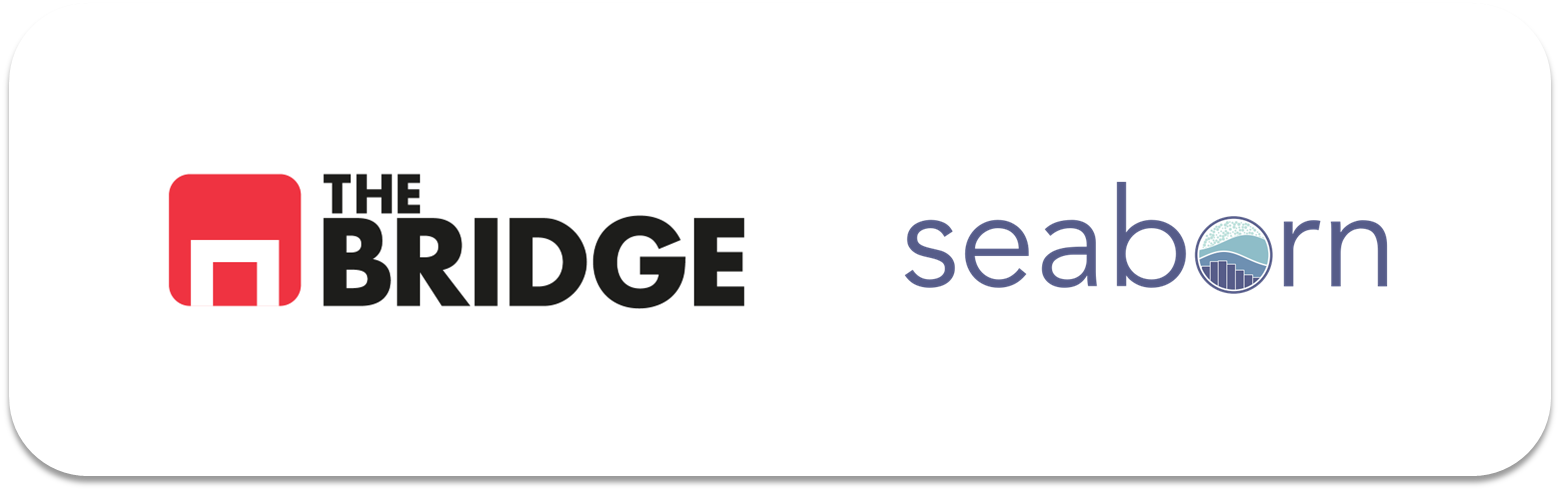

## PRACTICA OBLIGATORIA: **Visualización y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.options.mode.copy_on_write = True  # CoW activado por defecto desde pandas 3.0

## #1 VISUALIZACION

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [2]:
df_cal = pd.read_csv("./data/california_cities.csv", index_col=0)
print(f"Shape: {df_cal.shape} | Filas con nulos: {df_cal.isnull().any(axis=1).sum()}")

df_cal = df_cal.dropna()
print(f"Tras dropna: {df_cal.shape[0]} filas")

# comprobación rápida de que están las columnas que voy a usar
cols_necesarias = ["latd", "longd", "population_total", "area_total_km2"]
faltan = [c for c in cols_necesarias if c not in df_cal.columns]
if faltan:
    print(f"AVISO: columnas no encontradas → {faltan}")

df_cal.head()


Shape: (482, 13) | Filas con nulos: 55
Tras dropna: 427 filas


,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57


### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA OPCIONAL: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños.

In [3]:
def diagrama_dispersion(df, col_x, col_y, col_color=None, tamano=None, escala=1.0, barra_color=False):
    """
    Diagrama de dispersión. tamano puede ser un número o el nombre de una columna del df.
    Si col_color es numérica continua y barra_color=True → colorbar; si no, leyenda integrada.
    """
    for col in [col_x, col_y]:
        if col not in df.columns:
            raise ValueError(f"Columna '{col}' no encontrada en el DataFrame.")
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"'{col}' debe ser numérica.")

    fig, ax = plt.subplots(figsize=(12, 7))
    plot_df = df.copy()

    # sqrt para que el área visual sea más proporcional que escalar linealmente
    if isinstance(tamano, str):
        s_vals = np.sqrt(np.clip(plot_df[tamano].values.astype(float), 0, None)) * escala
    elif isinstance(tamano, (int, float)):
        s_vals = float(tamano)
    else:
        s_vals = 40.0

    # si tiene muchos valores únicos la tratamos como continua
    color_continuo = (
        col_color is not None
        and pd.api.types.is_numeric_dtype(plot_df[col_color])
        and plot_df[col_color].nunique() > 8
    )

    if color_continuo and barra_color:
        sc = ax.scatter(
            plot_df[col_x], plot_df[col_y],
            c=plot_df[col_color], s=s_vals,
            cmap="viridis", alpha=0.75,
            edgecolors="white", linewidths=0.3, zorder=3,
        )
        cb = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
        cb.set_label(col_color, fontsize=10)

        if isinstance(tamano, str):
            q_vals = [plot_df[tamano].quantile(q) for q in [0.1, 0.5, 0.9]]
            s_q = [np.sqrt(max(v, 0)) * escala for v in q_vals]
            handles = [
                plt.scatter([], [], s=sz, color="gray", alpha=0.6, label=f"{v:.0f}")
                for sz, v in zip(s_q, q_vals)
            ]
            ax.legend(handles=handles, title=tamano, loc="upper left",
                      framealpha=0.8, fontsize=9)
    else:
        kw = dict(data=plot_df, x=col_x, y=col_y, alpha=0.7, ax=ax,
                  edgecolor="white", linewidth=0.3)
        if col_color is not None:
            kw["hue"] = col_color
        if isinstance(tamano, str):
            plot_df["__size_plot"] = s_vals
            kw["size"] = "__size_plot"
            kw["sizes"] = (20, 500)
        elif isinstance(tamano, (int, float)):
            kw["s"] = float(tamano)
        sns.scatterplot(**kw)

    ax.set_xlabel(col_x, fontsize=11)
    ax.set_ylabel(col_y, fontsize=11)
    plt.tight_layout()
    return fig, ax


### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

Una vez calculado el logaritmo, también puedes probar a categorizar la población, aquí tienes un ejemplo de como podría salir para que lo tengas de referencia:

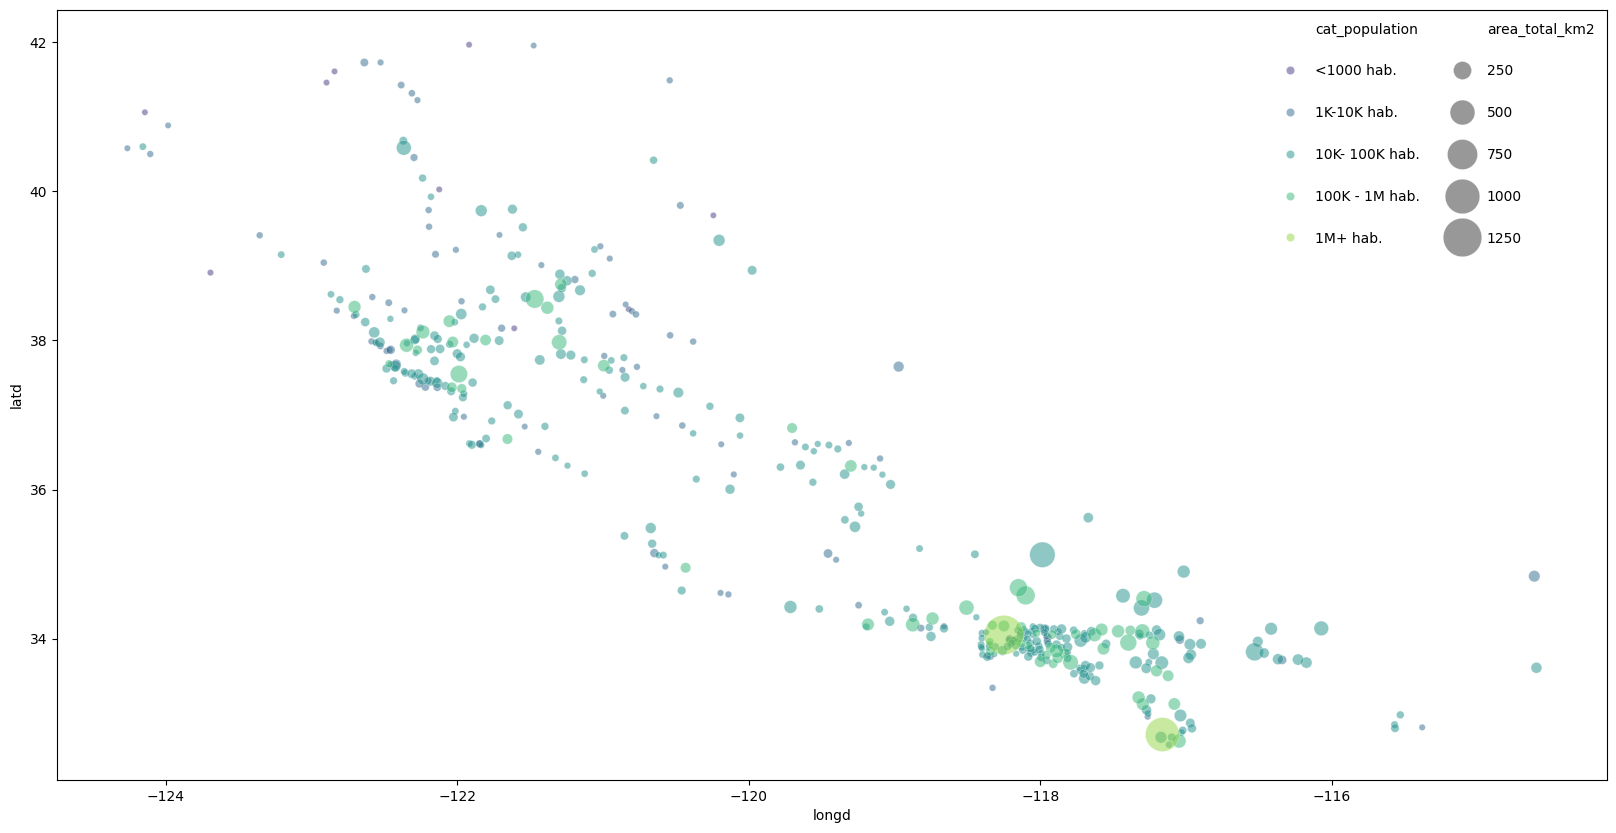

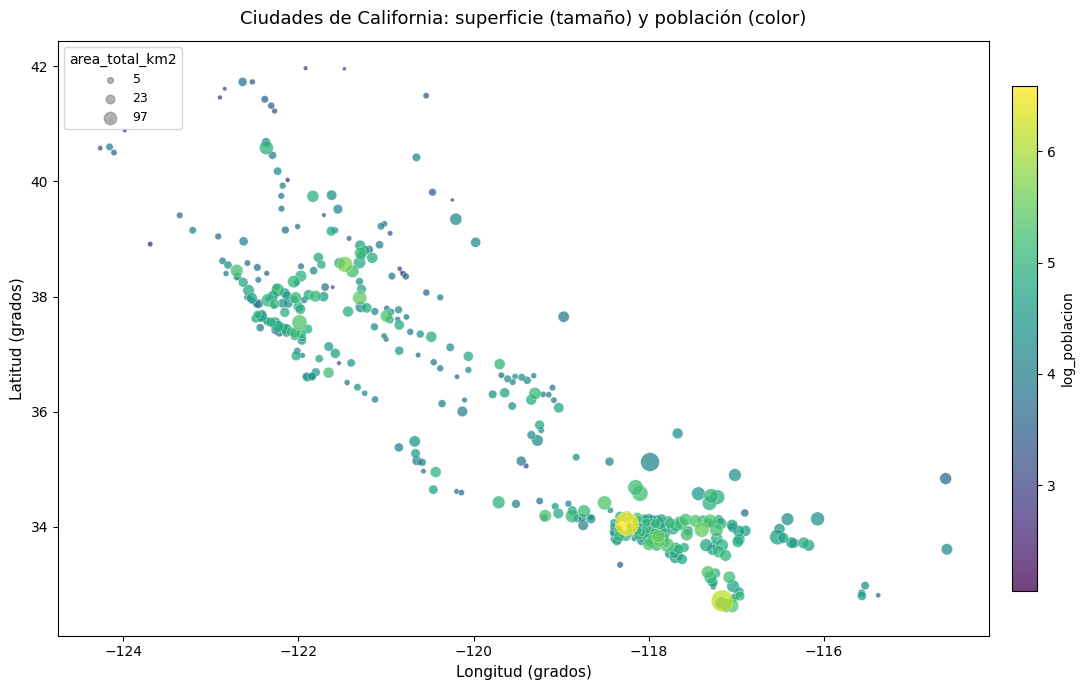

In [4]:
# Pomona aparece con 1 hab. en el dataset; corrijo con el valor real (~149k según el censo).
df_cal.loc[df_cal["city"] == "Pomona", "population_total"] = 149_058

df_cal["log_poblacion"] = np.log10(df_cal["population_total"])

# ordeno de menor a mayor para que las ciudades grandes queden encima y no tapen las pequeñas
df_plot = df_cal.sort_values("population_total")

fig, ax = diagrama_dispersion(
    df_plot,
    col_x="longd",
    col_y="latd",
    col_color="log_poblacion",
    tamano="area_total_km2",
    escala=8,          # con este valor los tamaños quedan bastante legibles
    barra_color=True,
)
ax.set_title("Ciudades de California: superficie (tamaño) y población (color)", fontsize=13, pad=12)
ax.set_xlabel("Longitud (grados)", fontsize=11)
ax.set_ylabel("Latitud (grados)", fontsize=11)
plt.tight_layout()
plt.show()


## #2: Presentación

En esta parte tendrás que hacer dos cosas, crear una presentación sobre el titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  
1- El titanic fue un accidente con una tasa de mortalidad alta.  
2- En esa ocasión los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3- ... que la clase en la que se viajes tuvo una influencia significativa y podría explicar...  
4- ... las diferencias de tasas de supervivencia entre mujeres y niños.    
5- Además aunque el puerto de embarque parece influir, se podría asumir que lo fue el tipo de pasaje que embarcó en cada uno.  

Y generar el notebook con las gráficas que vas a emplear en la presentación. Tienes que entregar ambas cosas.

In [5]:
df_t = pd.read_csv("./data/titanic.csv")
sns.set_theme(style="whitegrid")
orden_c = ["First", "Second", "Third"]
print(f"Dataset Titanic: {df_t.shape[0]} pasajeros, {df_t.shape[1]} variables")


Dataset Titanic: 891 pasajeros, 15 variables


#### Slide 1 — mortalidad general

Lo pongo en dos gráficos: el porcentaje solo puede sonar abstracto, pero ver 549 muertes frente a 342 supervivientes lo hace más concreto para la presentación.

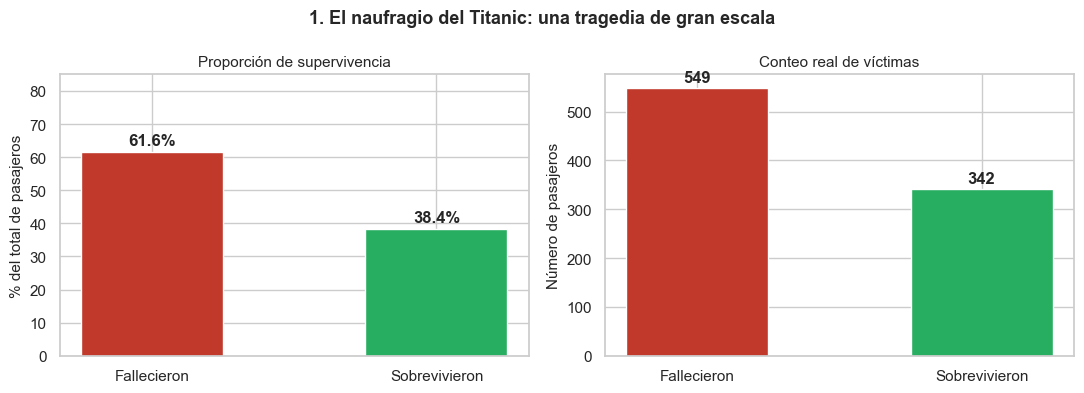

In [6]:
tasa_muerte = (df_t["alive"] == "no").mean() * 100
n_fallecidos = (df_t["alive"] == "no").sum()
n_sobrevivieron = (df_t["alive"] == "yes").sum()

etiq = ["Fallecieron", "Sobrevivieron"]
colores = ["#c0392b", "#27ae60"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# porcentaje
axes[0].bar(etiq, [tasa_muerte, 100 - tasa_muerte], color=colores,
            edgecolor="white", width=0.5)
axes[0].set_ylabel("% del total de pasajeros", fontsize=11)
axes[0].set_ylim(0, 85)
axes[0].set_title("Proporción de supervivencia", fontsize=11)
for bar, val in zip(axes[0].patches, [tasa_muerte, 100 - tasa_muerte]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")

# conteo real
axes[1].bar(etiq, [n_fallecidos, n_sobrevivieron], color=colores,
            edgecolor="white", width=0.5)
axes[1].set_ylabel("Número de pasajeros", fontsize=11)
axes[1].set_title("Conteo real de víctimas", fontsize=11)
for bar, val in zip(axes[1].patches, [n_fallecidos, n_sobrevivieron]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha="center", va="bottom", fontweight="bold")

fig.suptitle("1. El naufragio del Titanic: una tragedia de gran escala",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### Slide 2 — mujeres y niños primero

La diferencia entre grupos es bastante clara. El dato de los niños es interesante porque varía mucho según la clase, que es lo que se ve en el slide siguiente.

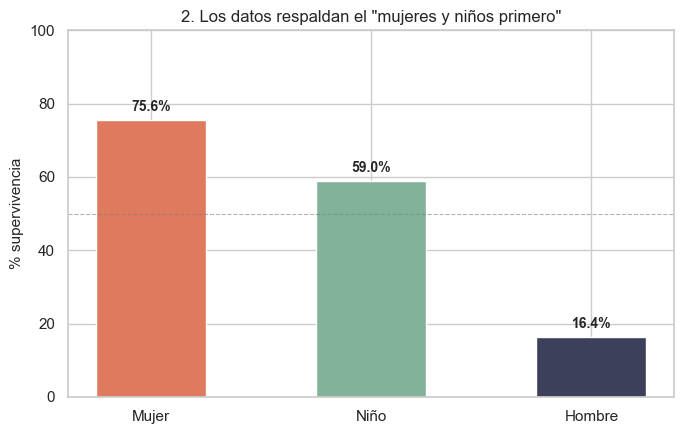

In [7]:
orden_who = ["woman", "child", "man"]
etiq_who = ["Mujer", "Niño", "Hombre"]

t_who = (
    df_t.groupby("who", observed=False)["alive"]
    .apply(lambda s: (s == "yes").mean() * 100)
    .reindex(orden_who)
)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(etiq_who, t_who.values,
              color=["#e07a5f", "#81b29a", "#3d405b"],
              edgecolor="white", width=0.5)
ax.set_ylabel("% supervivencia", fontsize=11)
ax.set_ylim(0, 100)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title('2. Los datos respaldan el "mujeres y niños primero"', fontsize=12)
for bar, val in zip(bars, t_who.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

#### Slides 3-4 — la clase lo complica todo

El heatmap sexo × clase es el gráfico que más me gusta de esta parte: de un vistazo se ve que las probabilidades reales dependen mucho de la combinación concreta, no solo del grupo.

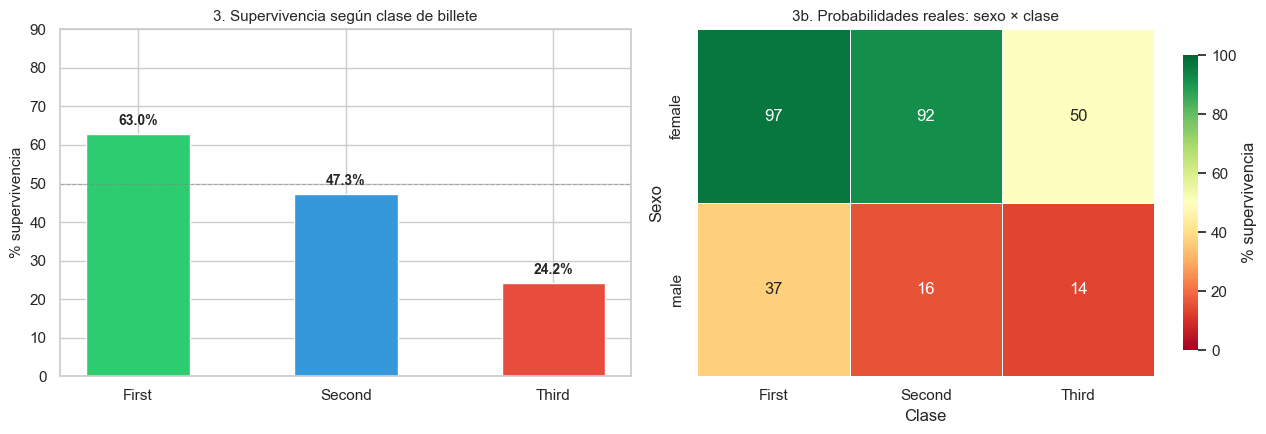

C:\Users\carlo\AppData\Local\Temp\ipykernel_4224\261587461.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Mujer", "Niño"], fontsize=11)


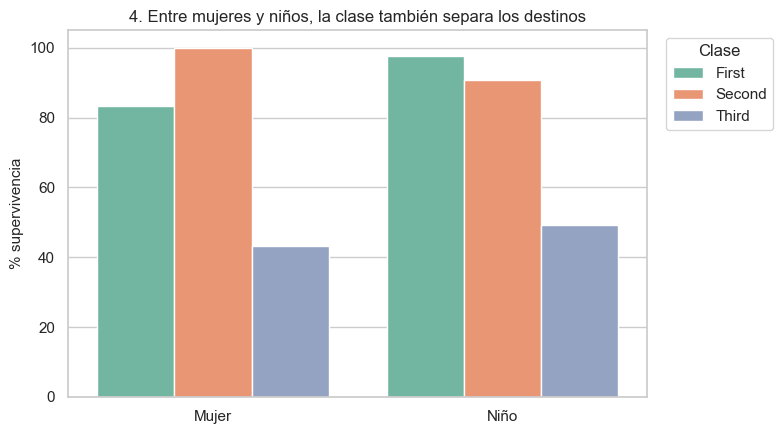

In [8]:
t_clase = (
    df_t.groupby("class", observed=False)["alive"]
    .apply(lambda s: (s == "yes").mean() * 100)
    .reindex(orden_c)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].bar(orden_c, t_clase.values,
                   color=["#2ecc71", "#3498db", "#e74c3c"],
                   edgecolor="white", width=0.5)
axes[0].set_ylabel("% supervivencia", fontsize=11)
axes[0].set_ylim(0, 90)
axes[0].axhline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
axes[0].set_title("3. Supervivencia según clase de billete", fontsize=11)
for bar, val in zip(bars, t_clase.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# heatmap sexo x clase — quería ver las probabilidades para cada combinación de golpe
pivot_hm = (
    df_t.groupby(["sex", "class"], observed=False)["alive"]
    .apply(lambda s: (s == "yes").mean() * 100)
    .unstack("class")[orden_c]
)
sns.heatmap(pivot_hm, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, ax=axes[1],
            cbar_kws={"label": "% supervivencia", "shrink": 0.85},
            linewidths=0.5)
axes[1].set_title("3b. Probabilidades reales: sexo × clase", fontsize=11)
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Sexo")

plt.tight_layout()
plt.show()

# slide 4: mujeres y niños por clase
sub_wc = df_t[df_t["who"].isin(["woman", "child"])]
tab_wc = (
    sub_wc.groupby(["who", "class"], observed=False)["alive"]
    .apply(lambda s: (s == "yes").mean() * 100)
    .reset_index(name="pct")
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=tab_wc, x="who", y="pct", hue="class", hue_order=orden_c,
            ax=ax, palette="Set2", edgecolor="white")
ax.set_xticklabels(["Mujer", "Niño"], fontsize=11)
ax.set_ylabel("% supervivencia", fontsize=11)
ax.set_xlabel("")
ax.set_ylim(0, 105)
ax.set_title("4. Entre mujeres y niños, la clase también separa los destinos", fontsize=12)
ax.legend(title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Slide 5 — el puerto

Las diferencias por puerto llaman la atención pero son sospechosas. Los dos gráficos de la derecha intentan mostrar que lo que de verdad varía es la composición de clase y de grupos, no el puerto en sí.

C:\Users\carlo\AppData\Local\Temp\ipykernel_4224\2015621334.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=t_puerto.index, y=t_puerto.values, ax=axes[0],


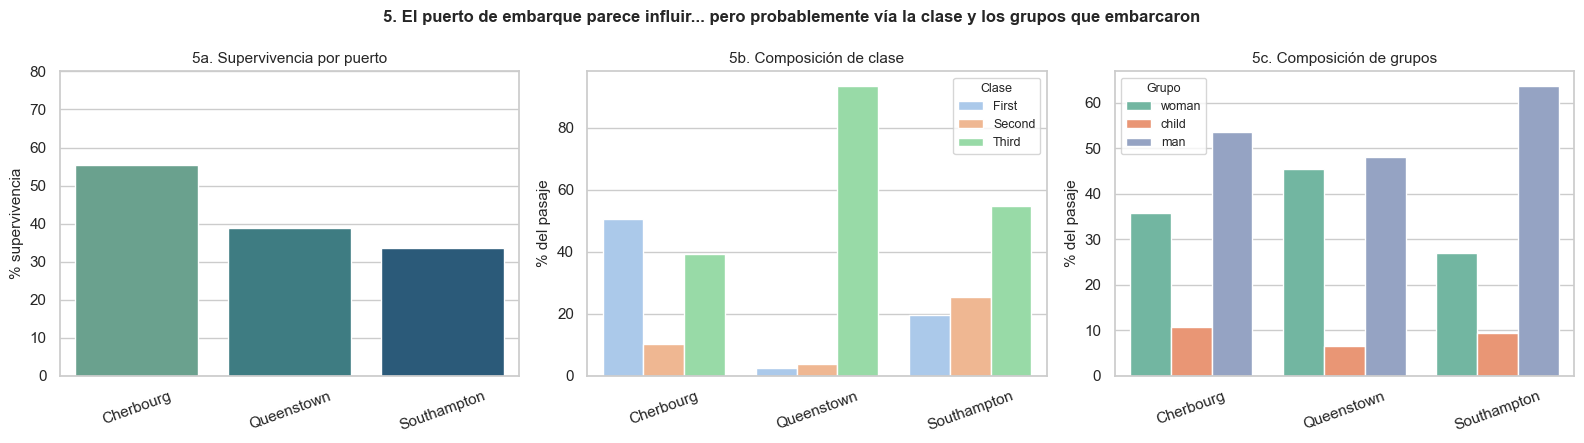

In [9]:
df_t_clean = df_t.dropna(subset=["embark_town"])

t_puerto = (
    df_t_clean.groupby("embark_town")["alive"]
    .apply(lambda s: (s == "yes").mean() * 100)
)
mix_clase = (
    df_t_clean.groupby("embark_town")["class"]
    .value_counts(normalize=True)
    .rename("frac").mul(100).reset_index()
)
mix_who = (
    df_t_clean.groupby("embark_town")["who"]
    .value_counts(normalize=True)
    .rename("frac").mul(100).reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# supervivencia por puerto
sns.barplot(x=t_puerto.index, y=t_puerto.values, ax=axes[0],
            palette="crest", edgecolor="white")
axes[0].set_ylabel("% supervivencia", fontsize=11)
axes[0].set_xlabel("")
axes[0].set_ylim(0, 80)
axes[0].set_title("5a. Supervivencia por puerto", fontsize=11)
axes[0].tick_params(axis="x", rotation=20)

# composición de clase por puerto
sns.barplot(data=mix_clase, x="embark_town", y="frac", hue="class",
            hue_order=orden_c, ax=axes[1], palette="pastel", edgecolor="white")
axes[1].set_ylabel("% del pasaje", fontsize=11)
axes[1].set_xlabel("")
axes[1].set_title("5b. Composición de clase", fontsize=11)
axes[1].legend(title="Clase", fontsize=9, title_fontsize=9)
axes[1].tick_params(axis="x", rotation=20)

# composición de grupos por puerto
sns.barplot(data=mix_who, x="embark_town", y="frac", hue="who",
            hue_order=["woman", "child", "man"], ax=axes[2],
            palette="Set2", edgecolor="white")
axes[2].set_ylabel("% del pasaje", fontsize=11)
axes[2].set_xlabel("")
axes[2].set_title("5c. Composición de grupos", fontsize=11)
axes[2].legend(title="Grupo", fontsize=9, title_fontsize=9)
axes[2].tick_params(axis="x", rotation=20)

fig.suptitle(
    "5. El puerto de embarque parece influir... pero probablemente vía la clase y los grupos que embarcaron",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()